In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model     import Ridge
from sklearn.preprocessing    import StandardScaler
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.metrics          import mean_absolute_error, r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/processed/epiclim_with_clusters.csv")
df['year_month'] = pd.to_datetime(df['year_month'])
print("Shape:", df.shape)

Shape: (6771, 17)


In [3]:
features = ['preci', 'Temp', 'LAI', 'Cases_MA_3', 'Case_Growth_Rate', 'Month']
target   = 'Cases'

In [4]:
print("\nFeature ranges BEFORE clipping:")
print(df[features + [target]].describe().loc[['min','max']])

for col in features + [target]:
    lo = df[col].quantile(0.01)
    hi = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lo, upper=hi)

print("\nFeature ranges AFTER clipping:")
print(df[features + [target]].describe().loc[['min','max']])


Feature ranges BEFORE clipping:
        preci     Temp   LAI  Cases_MA_3  Case_Growth_Rate  Month    Cases
min  0.000002  259.680   0.0        0.00          -0.99696    1.0     0.00
max  5.680000  327.728  62.0      836.56           5.00000   12.0  7923.48

Feature ranges AFTER clipping:
        preci      Temp   LAI  Cases_MA_3  Case_Growth_Rate  Month   Cases
min  0.000033  286.2815   2.0    5.783333         -0.952902    1.0    3.00
max  2.723679  321.2070  37.0  443.294667          5.000000   12.0  836.56


In [5]:
assert not np.isinf(df[features].values).any(), "Inf still present in features"
assert not df[features].isnull().any().any(),    "NaN still present in features"
print("\nNo inf or nan values — safe to proceed.")


No inf or nan values — safe to proceed.


In [7]:
X = df[features]   
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

In [9]:
assert not np.isinf(X_train_sc).any(), "Inf in scaled training data"
assert not np.isnan(X_train_sc).any(), "NaN in scaled training data"

In [15]:
models = {
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge Regression':     Ridge(alpha=1.0),
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'model': model}
    print(f"\n{name}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")


Random Forest
  MAE  : 26.53
  RMSE : 68.83
  R²   : 0.6606

Gradient Boosting
  MAE  : 27.65
  RMSE : 68.50
  R²   : 0.6638

Ridge Regression
  MAE  : 39.76
  RMSE : 85.11
  R²   : 0.4810


In [16]:
best_name  = max(results, key=lambda k: results[k]['R2'])
best_model = results[best_name]['model']
print(f"\nBest model: {best_name}  (R² = {results[best_name]['R2']:.4f})")


Best model: Gradient Boosting  (R² = 0.6638)



Feature importances:
 Cases_MA_3          0.656402
Case_Growth_Rate    0.313257
preci               0.011920
LAI                 0.011444
Temp                0.005337
Month               0.001640
dtype: float64


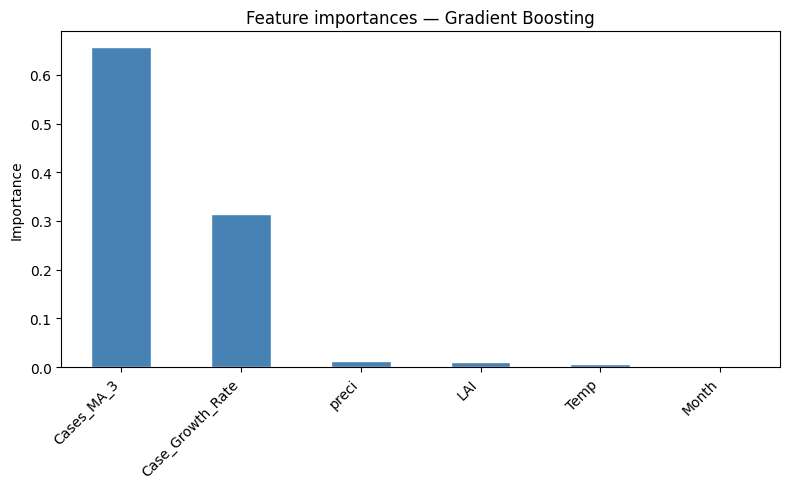

In [17]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=features)
    importances = importances.sort_values(ascending=False)
    print("\nFeature importances:\n", importances)

    plt.figure(figsize=(8, 5))
    importances.plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title(f'Feature importances — {best_name}')
    plt.ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("../outputs/feature_importances.png", dpi=150)
    plt.show()

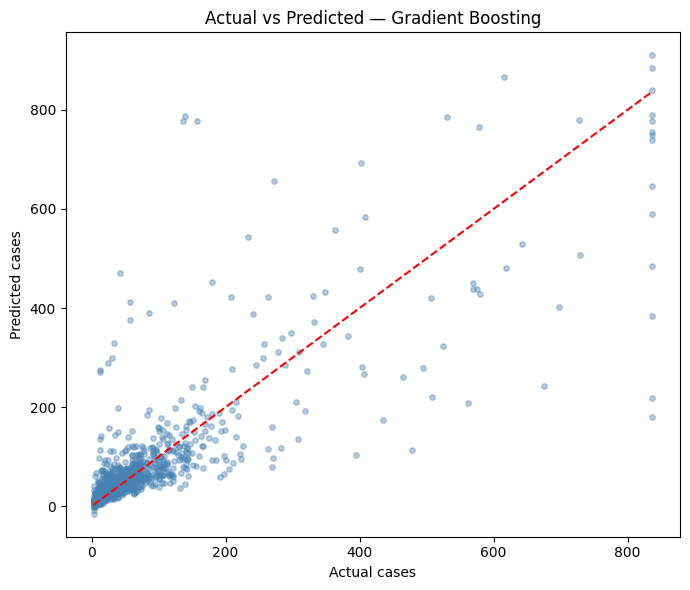

In [18]:
preds_best = best_model.predict(X_test_sc)
plt.figure(figsize=(7, 6))
plt.scatter(y_test, preds_best, alpha=0.4, s=15, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel('Actual cases')
plt.ylabel('Predicted cases')
plt.title(f'Actual vs Predicted — {best_name}')
plt.tight_layout()
plt.savefig("../outputs/actual_vs_predicted.png", dpi=150)
plt.show()

In [19]:
X_all_sc = scaler.transform(X)
cv_scores = cross_val_score(best_model, X_all_sc, y, cv=5, scoring='r2')
print(f"\n5-fold CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-fold CV R²: 0.7428 ± 0.0454


In [20]:
X_full_sc            = scaler.transform(X)
df['Predicted_Cases'] = best_model.predict(X_full_sc)

In [22]:
X_full_sc            = scaler.transform(X)
df['Predicted_Cases'] = best_model.predict(X_full_sc)

p33 = df['Predicted_Cases'].quantile(0.33)
p66 = df['Predicted_Cases'].quantile(0.66)

def risk_tier(v):
    if v >= p66:   return 'High Risk'
    elif v >= p33: return 'Medium Risk'
    else:          return 'Low Risk'

df['Predicted_Risk'] = df['Predicted_Cases'].apply(risk_tier)

print("\nPredicted risk distribution:")
print(df['Predicted_Risk'].value_counts())

df.to_csv("../data/processed/epiclim_with_predictions.csv", index=False)
print("\nSaved to ../data/processed/epiclim_with_predictions.csv")



Predicted risk distribution:
Predicted_Risk
High Risk      2302
Medium Risk    2235
Low Risk       2234
Name: count, dtype: int64

Saved to ../data/processed/epiclim_with_predictions.csv


In [23]:
print(df[['state_ut','district','year_month','Cases','Predicted_Cases','Predicted_Risk']].head(10))

                      state_ut                  district year_month  Cases  \
0  Andaman and Nicobar Islands                   Andaman 2019-06-01    8.0   
1  Andaman and Nicobar Islands                   Andaman 2019-10-01   30.0   
2  Andaman and Nicobar Islands  North and Middle Andaman 2013-12-01   86.0   
3               Andhra Pradesh                 Anantapur 2010-06-01   68.0   
4               Andhra Pradesh                 Anantapur 2011-06-01  128.0   
5               Andhra Pradesh                 Anantapur 2011-09-01   25.0   
6               Andhra Pradesh                 Anantapur 2012-05-01   25.0   
7               Andhra Pradesh                 Anantapur 2012-12-01   23.0   
8               Andhra Pradesh                 Anantapur 2013-06-01   59.0   
9               Andhra Pradesh                 Anantapur 2013-08-01   34.0   

   Predicted_Cases Predicted_Risk  
0        12.451892       Low Risk  
1        50.418876    Medium Risk  
2       100.150288      High Risk